# Customer Churn Prediction

# Exploratory Data Analysis

In [85]:
# import
import pandas as pd
df = pd.read_csv('datasets/Data_Science_Challenge.csv')

## Data Types

In [86]:
# data types of columns
def df_datatypes(df):
    df_desc = pd.DataFrame(df.dtypes.value_counts().reset_index())
    df_desc.columns = ['Data Type', 'Count']
    return df_desc.sort_values('Count', ascending=False)

df['area code'] = df['area code'].astype('category')

df_datatypes(df)

,Data Type,Count
0,float64,8
1,int64,7
2,object,4
3,category,1
4,bool,1


## Categorical

In [87]:
# categorical - describe
import numpy as np
def df_describe_categorical(df):
    return df.select_dtypes(exclude=np.number).describe()

df_describe_categorical(df)

,state,area code,phone number,international plan,voice mail plan,churn
count,3333,3333,3333,3333,3333,3333
unique,51,3,3333,2,2,2
top,WV,415,382-4657,no,no,False
freq,106,1655,1,3010,2411,2850


## Numerical

In [88]:
# numerical - describe
def df_describe_numerical(df):
    return df.select_dtypes(include=np.number).describe()

df_describe_numerical(df)

,account length,number vmail messages,total day minutes,total day calls,total day charge,total eve minutes,total eve calls,total eve charge,total night minutes,total night calls,total night charge,total intl minutes,total intl calls,total intl charge,customer service calls
count,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000
mean,101.064806,8.099010,179.775098,100.435644,30.562307,200.980348,100.114311,17.083540,200.872037,100.107711,9.039325,10.237294,4.479448,2.764581,1.562856
std,39.822106,13.688365,54.467389,20.069084,9.259435,50.713844,19.922625,4.310668,50.573847,19.568609,2.275873,2.791840,2.461214,0.753773,1.315491
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,23.200000,33.000000,1.040000,0.000000,0.000000,0.000000,0.000000
25%,74.000000,0.000000,143.700000,87.000000,24.430000,166.600000,87.000000,14.160000,167.000000,87.000000,7.520000,8.500000,3.000000,2.300000,1.000000
50%,101.000000,0.000000,179.400000,101.000000,30.500000,201.400000,100.000000,17.120000,201.200000,100.000000,9.050000,10.300000,4.000000,2.780000,1.000000
75%,127.000000,20.000000,216.400000,114.000000,36.790000,235.300000,114.000000,20.000000,235.300000,113.000000,10.590000,12.100000,6.000000,3.270000,2.000000
max,243.000000,51.000000,350.800000,165.000000,59.640000,363.700000,170.000000,30.910000,395.000000,175.000000,17.770000,20.000000,20.000000,5.400000,9.000000


<Axes: >

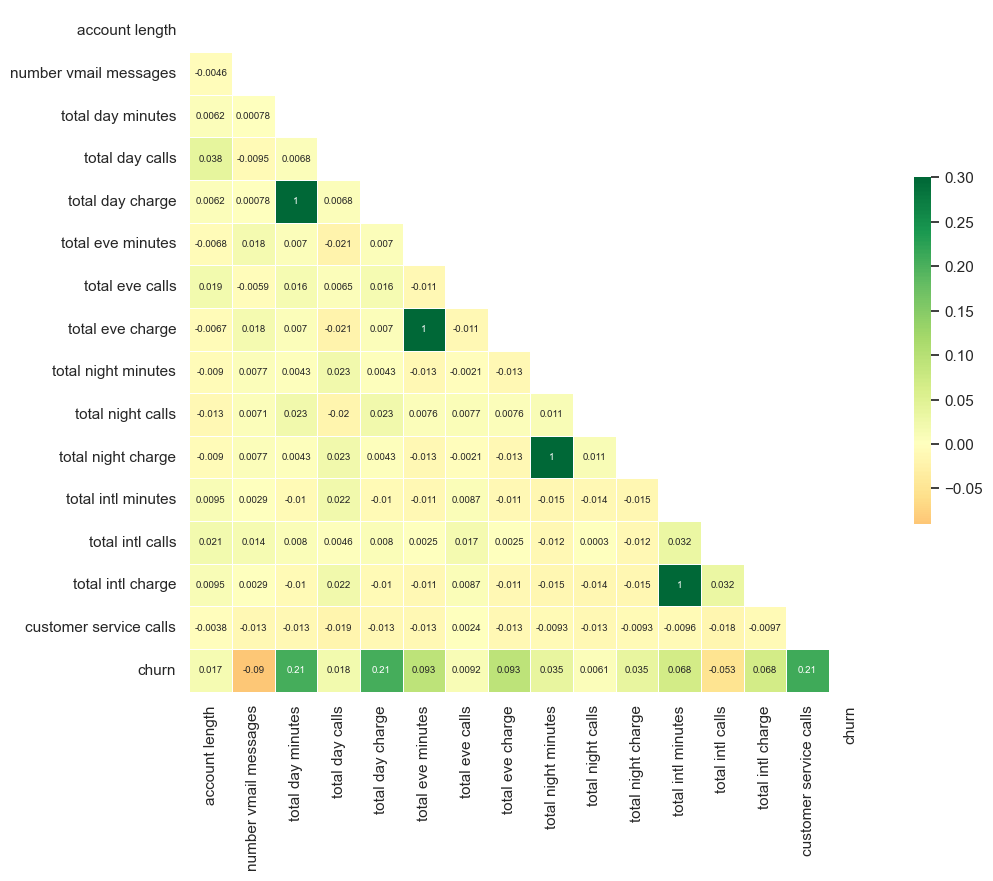

In [89]:
# numerical - correlogram
from matplotlib import pyplot as plt
import seaborn as sns
def graph_correlogram(df):
    sns.set_theme(style="white") 
    # Compute the correlation matrix
    corr = df.corr(numeric_only=True)
    # Generate a mask for the upper triangle
    mask = np.triu(np.ones_like(corr, dtype=bool))
    # Set up the matplotlib figure
    f, ax = plt.subplots(figsize=(11, 9))
    # Draw the heatmap with the mask and correct aspect ratio
    graph = sns.heatmap(corr, mask=mask, cmap='RdYlGn', vmax=.3, center=0, square=True, annot=True, linewidths=.5, cbar_kws={"shrink": .5, }, annot_kws={'size': 7})
    return graph

graph_correlogram(df)

In [90]:
# correlation matrix with p-values
import pingouin as pg
def df_correlation_matrix(df):
    numerical = df.select_dtypes(include=['int64', 'float']).columns.tolist()
    print(f'Pearson Correlation Matrix with P-Values')
    print(f'[Coef in Btm Tri / p-Values in Up Tri]')
    print(f'*** for <0.001, ** for <0.01, * for <0.05')
    print(f'-----------------------------------------')
    return df[numerical].rcorr(method='pearson').round(3)

df_correlation_matrix(df)

Pearson Correlation Matrix with P-Values
[Coef in Btm Tri / p-Values in Up Tri]
*** for <0.001, ** for <0.01, * for <0.05
-----------------------------------------


,account length,number vmail messages,total day minutes,total day calls,total day charge,total eve minutes,total eve calls,total eve charge,total night minutes,total night calls,total night charge,total intl minutes,total intl calls,total intl charge,customer service calls
account length,-,,,*,,,,,,,,,,,
number vmail messages,-0.005,-,,,,,,,,,,,,,
total day minutes,0.006,0.001,-,,***,,,,,,,,,,
total day calls,0.038,-0.01,0.007,-,,,,,,,,,,,
total day charge,0.006,0.001,1.0,0.007,-,,,,,,,,,,
total eve minutes,-0.007,0.018,0.007,-0.021,0.007,-,,***,,,,,,,
total eve calls,0.019,-0.006,0.016,0.006,0.016,-0.011,-,,,,,,,,
total eve charge,-0.007,0.018,0.007,-0.021,0.007,1.0,-0.011,-,,,,,,,
total night minutes,-0.009,0.008,0.004,0.023,0.004,-0.013,-0.002,-0.013,-,,***,,,,
total night calls,-0.013,0.007,0.023,-0.02,0.023,0.008,0.008,0.008,0.011,-,,,,,


## Missing Data

In [91]:
# dataframe missing
def df_missing_info(df):
    pd.set_option('display.max_columns', df.shape[1])
    pd.set_option('display.max_rows', df.shape[1])
    descriptive_df = pd.DataFrame()
    descriptive_df['column'] = df.columns
    descriptive_df['data type'] = df.dtypes.tolist()
    descriptive_df['# missing'] = [df[col].isnull().sum() for col in df]
    descriptive_df['% missing'] = np.round(descriptive_df['# missing'] / df.shape[0], 4)
    return descriptive_df

df_missing_info(df)

,column,data type,# missing,% missing
0,state,object,0,0.0
1,account length,int64,0,0.0
2,area code,category,0,0.0
3,phone number,object,0,0.0
4,international plan,object,0,0.0
5,voice mail plan,object,0,0.0
6,number vmail messages,int64,0,0.0
7,total day minutes,float64,0,0.0
8,total day calls,int64,0,0.0
9,total day charge,float64,0,0.0


## Anova (Churn vs df)

In [92]:
# anova df
import warnings
def get_anova_df(target, df):
    # filter warnings
    warnings.simplefilter(action='ignore', category=FutureWarning)
    numerical_columns = df.select_dtypes(include=np.number).columns.tolist()
    anova_df = pd.DataFrame()
    for num in numerical_columns:
        new_row = df.anova(dv=num, between=target, detailed=False)
        new_row['Target'] = num
        new_row = new_row.rename(columns={'Target':'Feature', 'Source':'Target'})
        anova_df = pd.concat([anova_df, new_row], axis='rows')
    anova_df = anova_df[['Target', 'Feature','F', 'p-unc', 'np2']]
    return anova_df

anova_df = get_anova_df('churn', df)

### Statistically Significant

In [93]:
anova_df.loc[
    anova_df['p-unc'] <= 0.05
]

,Target,Feature,F,p-unc,np2
0,churn,number vmail messages,27.035912,2.117522e-07,0.008051
0,churn,total day minutes,146.350785,5.300278e-33,0.042087
0,churn,total day charge,146.350657,5.300606e-33,0.042087
0,churn,total eve minutes,28.932577,8.011339e-08,0.008611
0,churn,total eve charge,28.926444,8.036524e-08,0.008609
0,churn,total night minutes,4.201496,4.046648e-02,0.001260
0,churn,total night charge,4.202136,4.045122e-02,0.001260
0,churn,total intl minutes,15.583468,8.057311e-05,0.004657
0,churn,total intl calls,9.327945,2.274701e-03,0.002793
0,churn,total intl charge,15.592581,8.018754e-05,0.004659


### Statistically Insignificant

In [94]:
anova_df.loc[
    anova_df['p-unc'] > 0.05
]

,Target,Feature,F,p-unc,np2
0,churn,account length,0.911598,0.339760,0.000274
0,churn,total day calls,1.135412,0.286701,0.000341
0,churn,total eve calls,0.283994,0.594131,0.000085
0,churn,total night calls,0.125631,0.723028,0.000038


## Histograms of Numerical

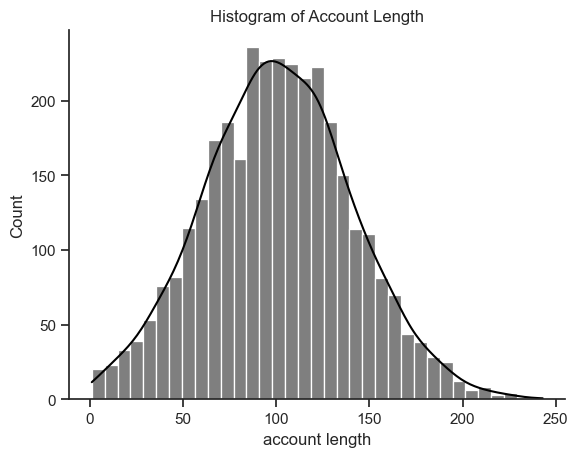

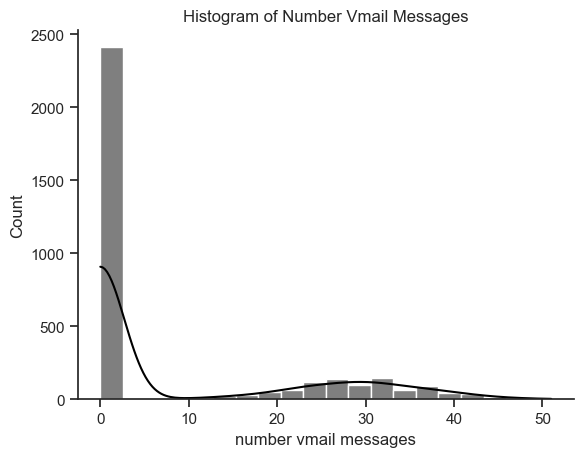

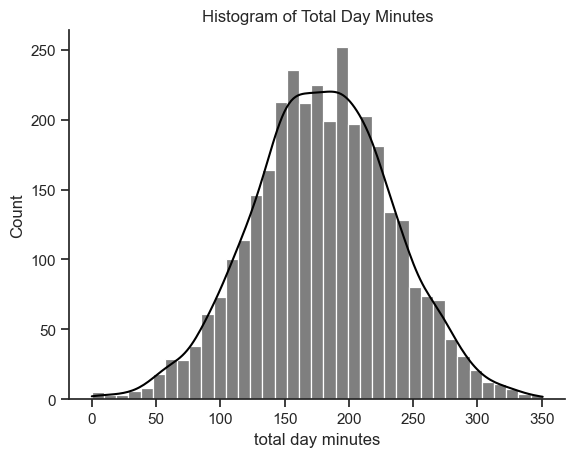

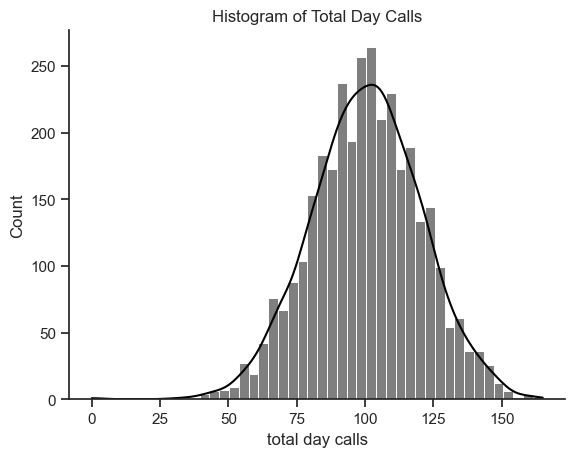

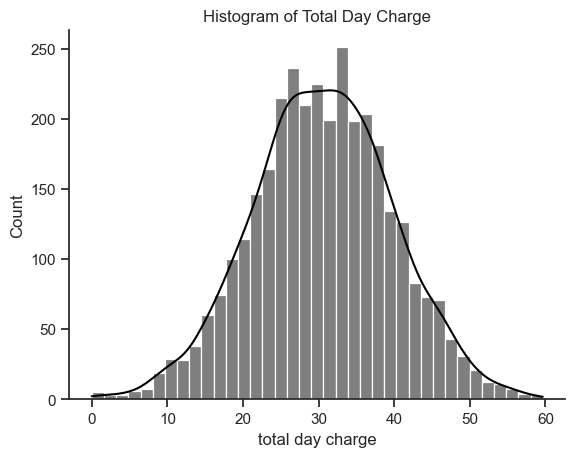

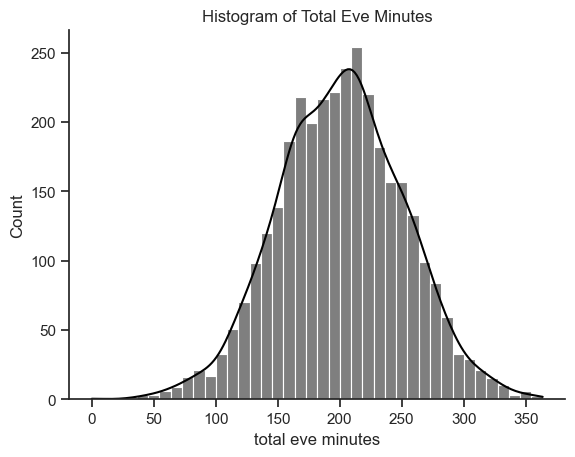

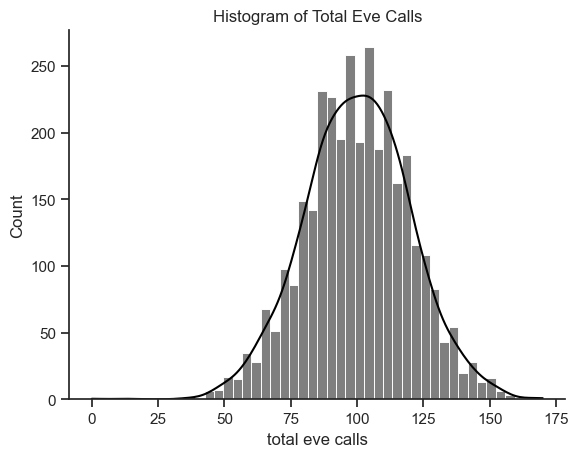

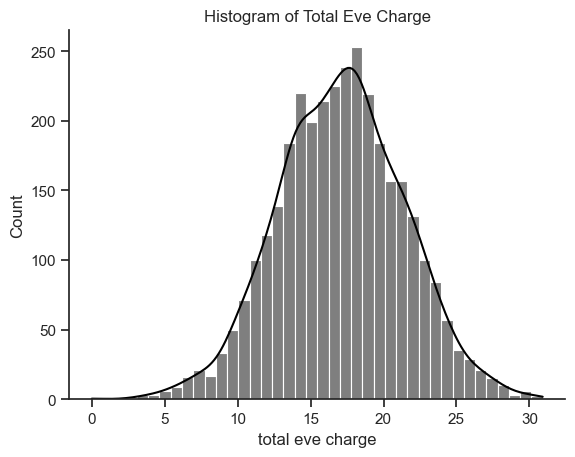

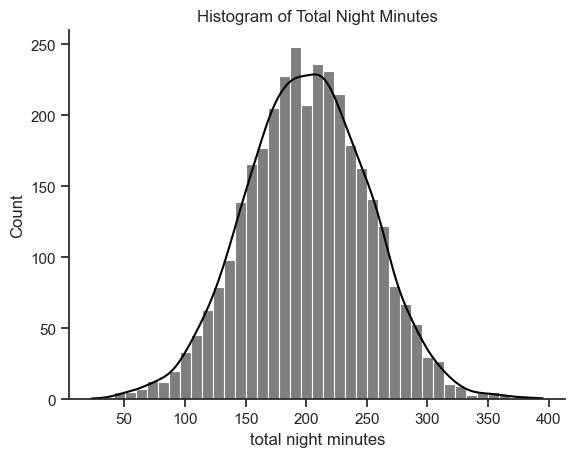

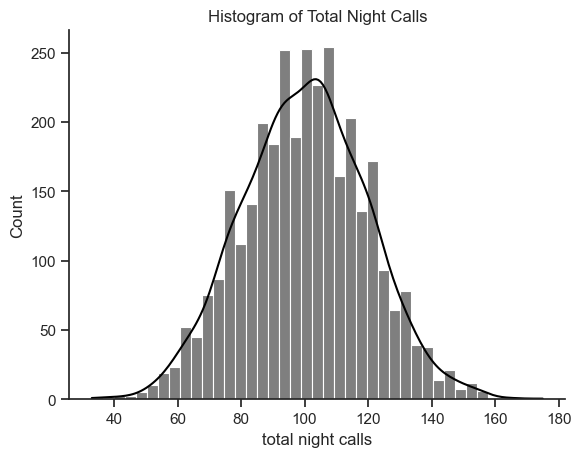

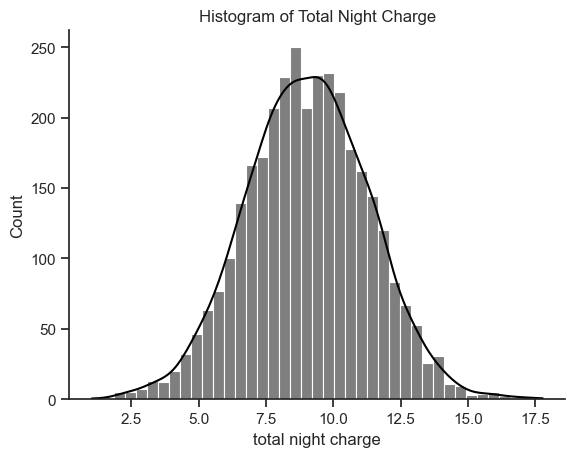

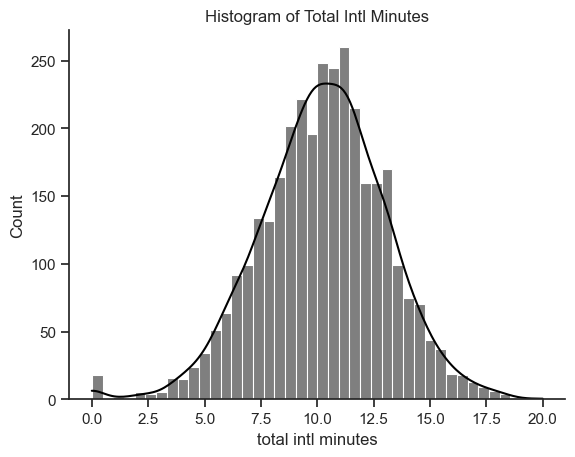

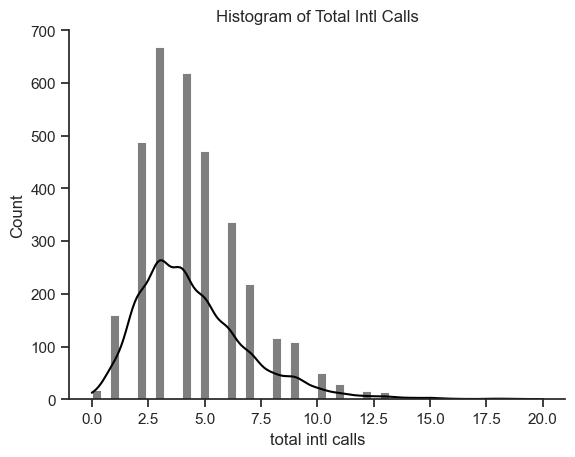

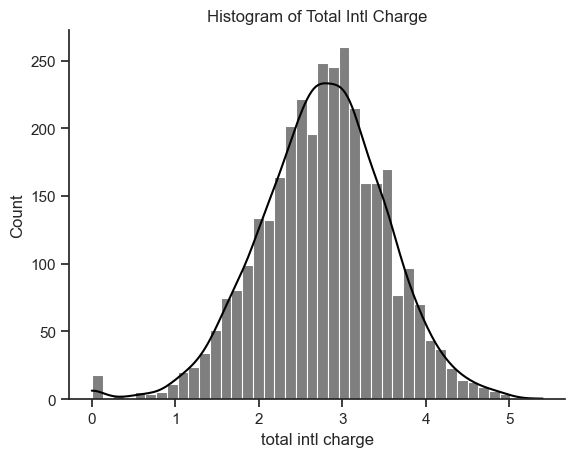

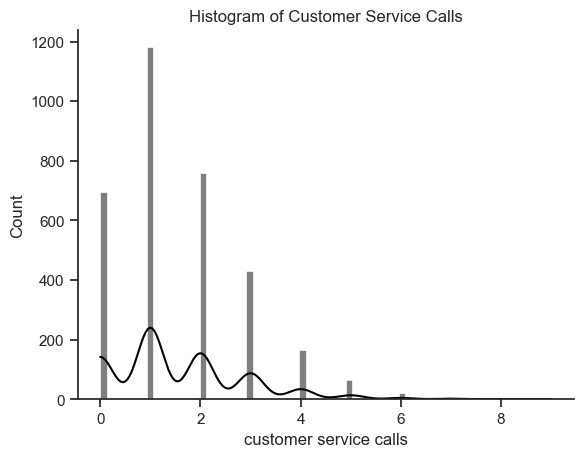

In [95]:
# graph of all numeric data types
def graph_numeric_histograms(df):
    custom_params = {"axes.spines.right": False, "axes.spines.top": False}
    sns.set_theme(style="ticks", rc=custom_params)
    numeric_columns = df.select_dtypes(include=np.number)
    for col in numeric_columns:
        sns.histplot(df[col], kde=True, color='black')
        plt.title(f'Histogram of {col.title()}')
        plt.show()
        
graph_numeric_histograms(df)

# Mutual Information Statistic

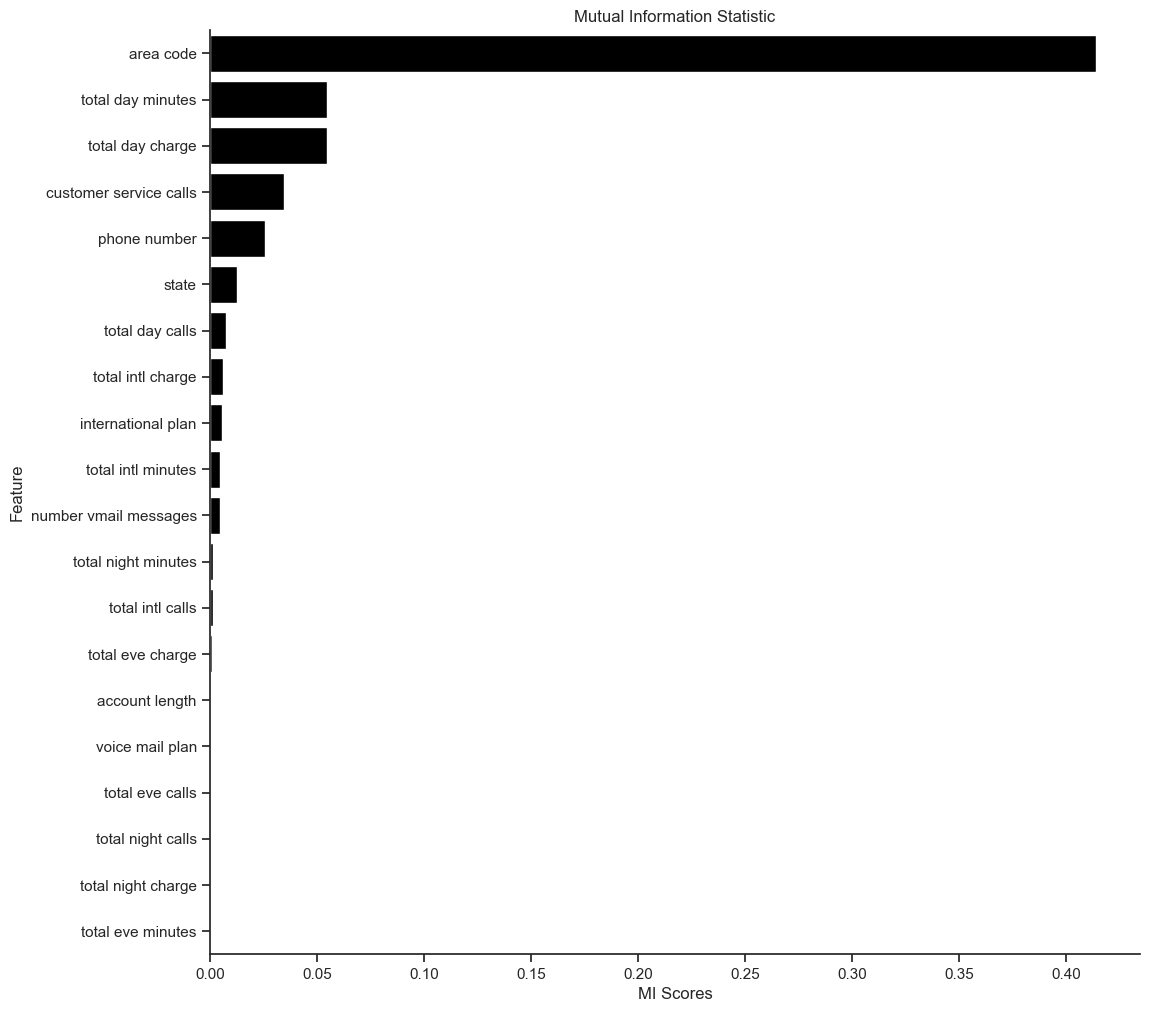

In [96]:
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, PowerTransformer, OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import mutual_info_classif

# separate x & y data
X = df.drop(['churn'], axis=1)
y = LabelEncoder().fit_transform(df['churn'])

# numeric pipeline
numeric_pipeline_steps = []
numeric_pipeline_steps.append(('min-max', MinMaxScaler(feature_range=(1, 2))))
numeric_pipeline_steps.append(('box-cox', PowerTransformer(method='box-cox')))
numeric_pipeline = Pipeline(steps=numeric_pipeline_steps)

# categorical pipeline
categorical_pipeline_steps = []
categorical_pipeline_steps.append(('oe', OrdinalEncoder(dtype=np.int64)))
categorical_pipeline = Pipeline(steps=categorical_pipeline_steps)

# create transformer
cat_columns = X.select_dtypes(exclude=[np.number]).columns.tolist()
num_columns = X.select_dtypes(include=[np.number]).columns.tolist()

transformer_steps = []
transformer_steps.append(('cat', categorical_pipeline, cat_columns))
transformer_steps.append(('num', numeric_pipeline, num_columns))
preprocessing_transformer=ColumnTransformer(transformers=transformer_steps)

# preprocessing transformer
preprocessing_transformer

# preprocess X data
pp_X = preprocessing_transformer.fit_transform(X)
pp_X_columns = pd.Series(preprocessing_transformer.get_feature_names_out()).str.replace('num__|cat__', '', regex=True)
pp_X_df = pd.DataFrame(pp_X, columns=pp_X_columns)

# get discrete feature indices
discrete_features_for_mi = [ind for ind, li in enumerate(pp_X_df.columns) if li in cat_columns]

# run mutual_info_classif
mi_scores = mutual_info_classif(pp_X_df, y, discrete_features=discrete_features_for_mi, random_state=2022)

# make df of mi
mi_scores_df = pd.DataFrame({'Feature': X.columns, 'MI Scores': mi_scores}).sort_values('MI Scores', ascending=False)

# bar plot
plt.figure(figsize=(12, 12))
sns.barplot(y='Feature', x='MI Scores', data=mi_scores_df, color='black')
plt.title('Mutual Information Statistic')
plt.show()

In [97]:
# dataframe of mi scores
mi_scores_df.round(3)

,Feature,MI Scores
2,area code,0.414
7,total day minutes,0.055
9,total day charge,0.055
19,customer service calls,0.034
3,phone number,0.026
0,state,0.012
8,total day calls,0.008
18,total intl charge,0.006
4,international plan,0.006
16,total intl minutes,0.005


# Model Preparation

In [98]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures, OneHotEncoder
from sklearn.compose import make_column_selector
from sklearn import set_config

# split into train, test data
X_train, X_test, y_train, y_test = train_test_split(
    df.drop('churn', axis='columns'),
    df['churn'],
    stratify=df['churn'],
    test_size=0.30,
    random_state=2022
    )

# Numeric Feature Pipeline
numeric_pipeline_steps = []
numeric_pipeline_steps.append(('scaler', StandardScaler()))
numeric_pipeline_steps.append(('poly', PolynomialFeatures(degree=2)))
numeric_pipeline = Pipeline(steps=numeric_pipeline_steps)

# Categorical Feature Pipeline
categorical_pipeline_steps = []
categorical_pipeline_steps.append(('onehot', OneHotEncoder(handle_unknown='ignore')))
categorical_pipeline = Pipeline(steps=categorical_pipeline_steps)

# Preprocessing Transformer
transformer_steps = []
transformer_steps.append(('cat', categorical_pipeline, make_column_selector(dtype_exclude=np.number)))
transformer_steps.append(('num', numeric_pipeline, make_column_selector(dtype_include=np.number)))
preprocessing_transformer=ColumnTransformer(transformers=transformer_steps)

# Display Transformer
set_config(display='diagram')
preprocessing_transformer

ColumnTransformer(transformers=[('cat',
                                 Pipeline(steps=[('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 <sklearn.compose._column_transformer.make_column_selector object at 0x13e8ae470>),
                                ('num',
                                 Pipeline(steps=[('scaler', StandardScaler()),
                                                 ('poly',
                                                  PolynomialFeatures())]),
                                 <sklearn.compose._column_transformer.make_column_selector object at 0x13e8afe80>)])

In [99]:
# Models
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import (AdaBoostClassifier, RandomForestClassifier)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

models = []
models.append(('DC', DummyClassifier(strategy='most_frequent')))
models.append(('AB-C', AdaBoostClassifier(n_estimators=1000, random_state=2022)))
models.append(('LR', LogisticRegression(solver='saga', penalty='elasticnet', class_weight='balanced', l1_ratio=0.5, max_iter=100_000, random_state=2022)))
models.append(('RF', RandomForestClassifier(n_estimators=1000, class_weight='balanced', random_state=2022)))
models.append(('DTC', DecisionTreeClassifier()))
models.append(('KNN', KNeighborsClassifier(weights='distance')))
models.append(('SVC-L', SVC(kernel='linear', class_weight='balanced')))
models.append(('SVC-P', SVC(kernel='poly', class_weight='balanced')))
models.append(('SVC-R', SVC(kernel='rbf', class_weight='balanced')))
models.append(('SVC-S', SVC(kernel='sigmoid', class_weight='balanced')))
models.append(('XGB-C', XGBClassifier(eval_metric='logloss', seed=2022)))

# Spot Check Algorithms

In [100]:
# results dataframe
results = pd.DataFrame()

# scoring used
scoring = 'accuracy'

# CV
from sklearn.model_selection import StratifiedKFold, cross_val_score
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=2022)

for name, model in models:
    # Pipeline
    model_pipeline_steps = []
    model_pipeline_steps.append(('transformer', preprocessing_transformer))
    model_pipeline_steps.append(('model', model))
    pipeline = Pipeline(steps=model_pipeline_steps)
    # CV results
    cv_results = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    temp_df = pd.DataFrame({name: pd.Series(abs(cv_results))})
    results = pd.concat([results, temp_df], axis='columns')
    # Mean +/- std
    msg = f'{name}: {cv_results.mean().round(5)} \u00B1 {cv_results.std().round(5)}'
    print(msg)

DC: 0.85512 ± 0.00165
AB-C: 0.90999 ± 0.01283
LR: 0.86369 ± 0.03341
RF: 0.88256 ± 0.00738
DTC: 0.93956 ± 0.01378
KNN: 0.88599 ± 0.0135
SVC-L: 0.89156 ± 0.02613
SVC-P: 0.89584 ± 0.01539
SVC-R: 0.8937 ± 0.01065
SVC-S: 0.73465 ± 0.02858
XGB-C: 0.95114 ± 0.00963


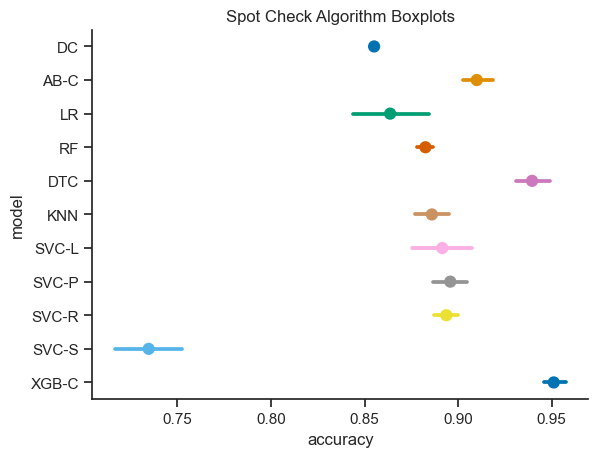

In [101]:
# Algorithm Comparison Boxplot
sns.pointplot(y='model', x=scoring,
            data=pd.melt(results, var_name='model', value_name=scoring), palette='colorblind')
plt.title('Spot Check Algorithm Boxplots')
plt.show()

In [102]:
# print df
results


,DC,AB-C,LR,RF,DTC,KNN,SVC-L,SVC-P,SVC-R,SVC-S,XGB-C
0,0.854701,0.897436,0.871795,0.867521,0.944444,0.863248,0.867521,0.897436,0.897436,0.747863,0.948718
1,0.854701,0.901709,0.850427,0.876068,0.940171,0.888889,0.880342,0.893162,0.884615,0.735043,0.952991
2,0.854701,0.918803,0.876068,0.893162,0.940171,0.884615,0.905983,0.910256,0.901709,0.786325,0.948718
3,0.858369,0.935622,0.905579,0.888412,0.948498,0.905579,0.935622,0.888412,0.905579,0.742489,0.952790
4,0.858369,0.909871,0.884120,0.879828,0.927039,0.879828,0.909871,0.879828,0.896996,0.755365,0.944206
5,0.854077,0.927039,0.901288,0.879828,0.948498,0.884120,0.896996,0.909871,0.896996,0.746781,0.961373
6,0.854077,0.909871,0.892704,0.892704,0.969957,0.905579,0.922747,0.922747,0.909871,0.725322,0.974249
7,0.854077,0.892704,0.828326,0.884120,0.922747,0.866953,0.884120,0.888412,0.888412,0.733906,0.944206
8,0.854077,0.905579,0.815451,0.879828,0.922747,0.884120,0.849785,0.866953,0.875536,0.686695,0.939914
9,0.854077,0.901288,0.811159,0.884120,0.931330,0.896996,0.862661,0.901288,0.879828,0.686695,0.944206


In [103]:
pd.DataFrame({
    'mean':results.mean(),
    'std':results.std()
    }).sort_values('mean', ascending=True)

,mean,std
SVC-S,0.734648,0.030129
DC,0.855123,0.001735
LR,0.863692,0.035213
RF,0.882559,0.007783
KNN,0.885993,0.014234
SVC-L,0.891565,0.027540
SVC-R,0.893698,0.011231
SVC-P,0.895837,0.016225
AB-C,0.909992,0.013522
DTC,0.939560,0.014523


# Tuning Best Model

In [104]:
# Model 
tune_model = XGBClassifier(n_estimators=1_000, eval_metric='logloss', seed=2022)

# Scoring
scoring = 'accuracy'

# Pipeline Steps
model_pipeline_steps = []
model_pipeline_steps.append(('transformer', preprocessing_transformer))
model_pipeline_steps.append(('model', tune_model))
model_pipeline = Pipeline(steps=model_pipeline_steps)

# Param Grid
tune_model.get_params()
model_pipeline.get_params()
param_grid = {
    'model__learning_rate': np.linspace(0.01, 0.2, 50),
    'model__max_depth': np.arange(2, 11, 1, dtype=int),
    'model__subsample': np.linspace(0.5, 1.0, 50),
    'model__colsample_bytree': np.linspace(0.5, 1.0, 50),
    }

# BayesSearchCV
from skopt import BayesSearchCV
bs_model = BayesSearchCV(
    estimator=model_pipeline,
    search_spaces=param_grid,
    scoring=scoring,
	n_iter=30,
    n_jobs=-1,
    random_state=2022
    )

# Display Model
bs_model

BayesSearchCV(estimator=Pipeline(steps=[('transformer',
                                         ColumnTransformer(transformers=[('cat',
                                                                          Pipeline(steps=[('onehot',
                                                                                           OneHotEncoder(handle_unknown='ignore'))]),
                                                                          <sklearn.compose._column_transformer.make_column_selector object at 0x13e8ae470>),
                                                                         ('num',
                                                                          Pipeline(steps=[('scaler',
                                                                                           StandardScaler()),
                                                                                          ('poly',
                                                                                           PolynomialFeatures())]),
                                                                          <sklearn.compose._column_t...
       0.65306122, 0.66326531, 0.67346939, 0.68367347, 0.69387755,
       0.70408163, 0.71428571, 0.7244898 , 0.73469388, 0.74489796,
       0.75510204, 0.76530612, 0.7755102 , 0.78571429, 0.79591837,
       0.80612245, 0.81632653, 0.82653061, 0.83673469, 0.84693878,
       0.85714286, 0.86734694, 0.87755102, 0.8877551 , 0.89795918,
       0.90816327, 0.91836735, 0.92857143, 0.93877551, 0.94897959,
       0.95918367, 0.96938776, 0.97959184, 0.98979592, 1.        ])})

In [105]:
# Fit Model on Train
bs_model.fit(X_train, y_train)

BayesSearchCV(estimator=Pipeline(steps=[('transformer',
                                         ColumnTransformer(transformers=[('cat',
                                                                          Pipeline(steps=[('onehot',
                                                                                           OneHotEncoder(handle_unknown='ignore'))]),
                                                                          <sklearn.compose._column_transformer.make_column_selector object at 0x13e8ae470>),
                                                                         ('num',
                                                                          Pipeline(steps=[('scaler',
                                                                                           StandardScaler()),
                                                                                          ('poly',
                                                                                           PolynomialFeatures())]),
                                                                          <sklearn.compose._column_t...
       0.65306122, 0.66326531, 0.67346939, 0.68367347, 0.69387755,
       0.70408163, 0.71428571, 0.7244898 , 0.73469388, 0.74489796,
       0.75510204, 0.76530612, 0.7755102 , 0.78571429, 0.79591837,
       0.80612245, 0.81632653, 0.82653061, 0.83673469, 0.84693878,
       0.85714286, 0.86734694, 0.87755102, 0.8877551 , 0.89795918,
       0.90816327, 0.91836735, 0.92857143, 0.93877551, 0.94897959,
       0.95918367, 0.96938776, 0.97959184, 0.98979592, 1.        ])})

In [106]:
# best score
print(f'best {scoring} score: {abs(bs_model.best_score_).round(5)}')

best accuracy score: 0.95285


In [107]:
# best params
best_param_df = pd.DataFrame(bs_model.best_params_.items(), columns=['Parameter', 'Value'])
best_param_df['Parameter'] = best_param_df['Parameter'].str.replace('model__', '')
best_param_df['Value'] = np.round(best_param_df['Value'], 4)
best_param_df

,Parameter,Value
0,colsample_bytree,0.6429
1,learning_rate,0.0449
2,max_depth,10.0000
3,subsample,0.8061


In [108]:
# best estimator
best_model_pipeline = bs_model.best_estimator_

# Area under Curve

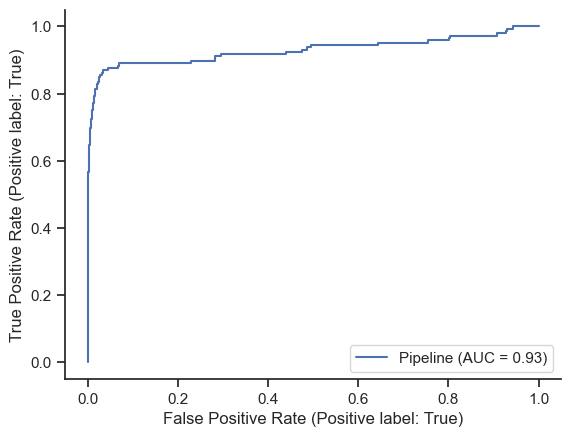

In [109]:
# ROC AUC on Test Set
from sklearn.metrics import RocCurveDisplay
RocCurveDisplay.from_estimator(
    estimator=best_model_pipeline,
    X=X_test,
    y=y_test
    )
plt.show()

# Confusion Matrix

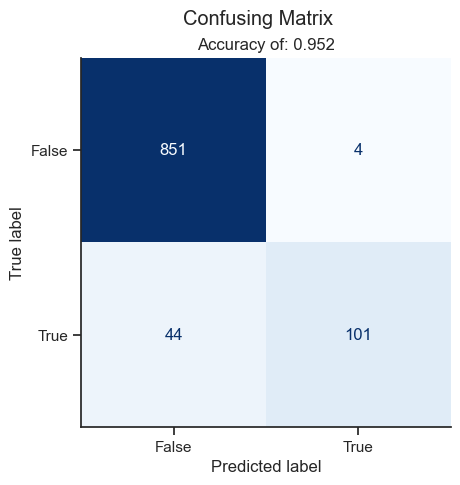

In [110]:
# Confusion on Test Set
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score
ConfusionMatrixDisplay.from_estimator(
    estimator=best_model_pipeline,
    X=X_test,
    y=y_test,
    cmap='Blues',
    colorbar=False)
plt.suptitle('Confusing Matrix')
plt.title(f'Accuracy of: {accuracy_score(y_true=y_test, y_pred=best_model_pipeline.predict(X_test))}')
plt.show()

# Saving Model

In [111]:
# Save Model
from datetime import datetime
import joblib
model_name = 'XGB-C'
model_file_name = f'models/{model_name} on {datetime.now().strftime("%Y %b %d at %H.%M.%S")}.pkl'
joblib.dump(best_model_pipeline, model_file_name)

['models/XGB-C on 2023 Apr 28 at 15.20.02.pkl']